# Customer Churn Prediction & Retention Recommendation System



### Business problem
Telecom companies lose revenue when customers leave. This project builds an end-to-end machine-learning workflow to:

- predict customer churn probability
- identify high-risk customers
- optimize the classification threshold using a **validation set**
- evaluate the final model on an **untouched test set**
- explain predictions with **SHAP**
- generate practical retention recommendations
- save the complete model + threshold as a reusable artifact
- upload new customer data and generate deployment-style predictions

### Project workflow
1. Business understanding
2. Data loading and quality checks
3. Data cleaning
4. Exploratory data analysis (EDA)
5. Business insights
6. Train / validation / test split
7. Preprocessing pipeline
8. Baseline + Logistic Regression + Random Forest + XGBoost
9. Cross-validated hyperparameter tuning
10. Validation-based threshold optimization
11. Final refit and untouched test evaluation
12. SHAP explainability
13. Risk segmentation
14. Retention recommendations
15. Save model + threshold artifact
16. Predict completely new customers
17. Export prediction results

> **Important modeling principle:** the test set is kept untouched until the final evaluation. The operating threshold is selected on validation data, not on the final test set.

## 1. Install dependencies


In [1]:
# Google Colab / notebook environment
!pip -q install pandas numpy matplotlib seaborn scikit-learn xgboost shap joblib

## 2. Imports and configuration

In [2]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve
)

from xgboost import XGBClassifier
import shap

from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42
MODEL_ARTIFACT_PATH = "customer_churn_model_artifact.joblib"
PREDICTIONS_PATH = "customer_churn_predictions.csv"

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 3. Business understanding

**Target:** `Churn`

**Objective:** predict which customers are likely to leave and turn those predictions into actionable retention priorities.

### Why this is a classification problem
The target has two outcomes:

- `0` = customer does not churn
- `1` = customer churns

### Why accuracy alone is not enough
Churn data is usually imbalanced. A model can achieve good accuracy while missing many actual churners. Therefore, this project reports:

- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Confusion matrix

The final operating threshold is optimized on validation data using **maximum F1-score**. In a real business deployment, the threshold could instead be selected using retention profit, contact-center capacity, or the relative cost of false positives and false negatives.

## 4. Upload and load the dataset

In [3]:
# Google Colab upload with a local fallback
try:
    from google.colab import files
    uploaded = files.upload()
    csv_files = [name for name in uploaded.keys() if name.lower().endswith(".csv")]
    if not csv_files:
        raise FileNotFoundError("No CSV file was uploaded.")
    DATA_PATH = csv_files[0]
except ImportError:
    candidates = [
        "WA_Fn-UseC_-Telco-Customer-Churn.csv",
        "/mnt/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
    ]
    DATA_PATH = next((p for p in candidates if os.path.exists(p)), None)
    if DATA_PATH is None:
        raise FileNotFoundError(
            "Place the Telco Customer Churn CSV in the working directory."
        )

df = pd.read_csv(DATA_PATH)

print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df.shape}")
display(df.head())

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv
Loaded: WA_Fn-UseC_-Telco-Customer-Churn (1).csv
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 5. Data understanding and quality checks

In [4]:
print("Dataset shape:", df.shape)

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_values"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(df["Churn"].value_counts(dropna=False).to_frame("count"))

print("\nTarget percentage:")
display((df["Churn"].value_counts(normalize=True) * 100).round(2).to_frame("percentage"))

Dataset shape: (7043, 21)

Data types:


,dtype
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



Missing values:


,missing_values
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



Duplicate rows: 0

Target distribution:


,count
Churn,
No,5174
Yes,1869



Target percentage:


,percentage
Churn,
No,73.46
Yes,26.54


## 6. Data cleaning

Key cleaning decisions:

- `customerID` is an identifier, so it is excluded from modeling.
- `TotalCharges` is converted from text to numeric.
- `Churn` is encoded as 0/1.
- Rows with a missing target are removed.
- Missing predictor values are handled inside the preprocessing pipeline to avoid leakage.

In [5]:
data = df.copy()

# Preserve a clean customer identifier separately for reference if needed.
customer_ids_original = data["customerID"].copy() if "customerID" in data.columns else None

# Identifier is not a predictive feature.
if "customerID" in data.columns:
    data = data.drop(columns=["customerID"])

# Convert TotalCharges to numeric.
if "TotalCharges" in data.columns:
    data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

# Encode target.
if "Churn" in data.columns:
    data["Churn"] = data["Churn"].map({"Yes": 1, "No": 0})

# Remove rows with missing target.
data = data.dropna(subset=["Churn"]).copy()
data["Churn"] = data["Churn"].astype(int)

print("Cleaned shape:", data.shape)
print("Missing target:", data["Churn"].isna().sum())
display(data.head())

Cleaned shape: (7043, 20)
Missing target: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 7. Exploratory Data Analysis (EDA)

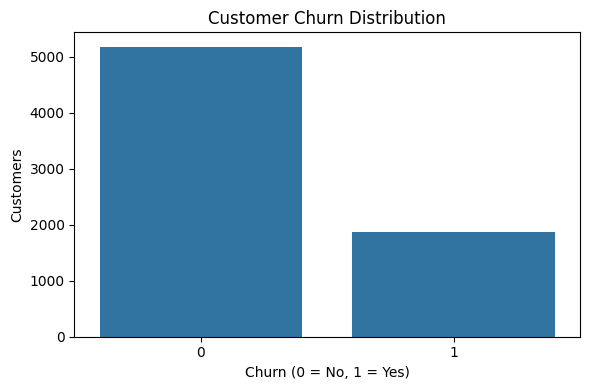

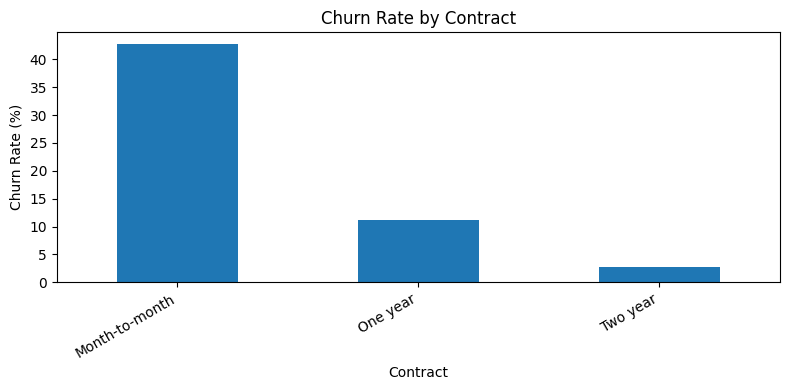

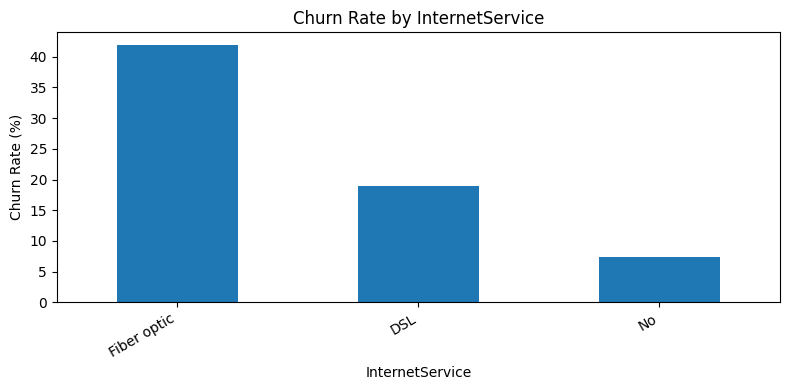

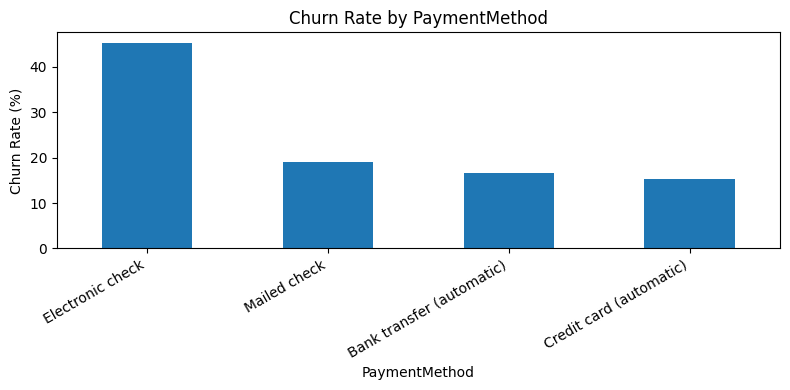

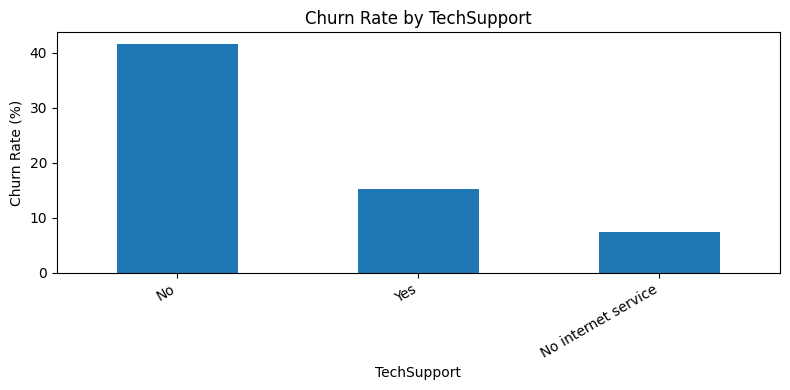

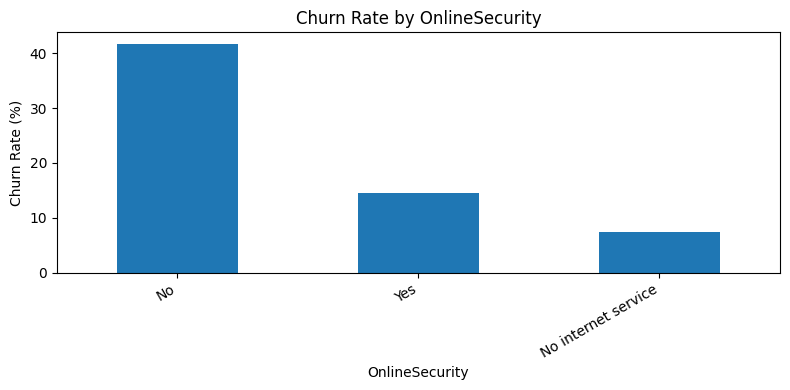

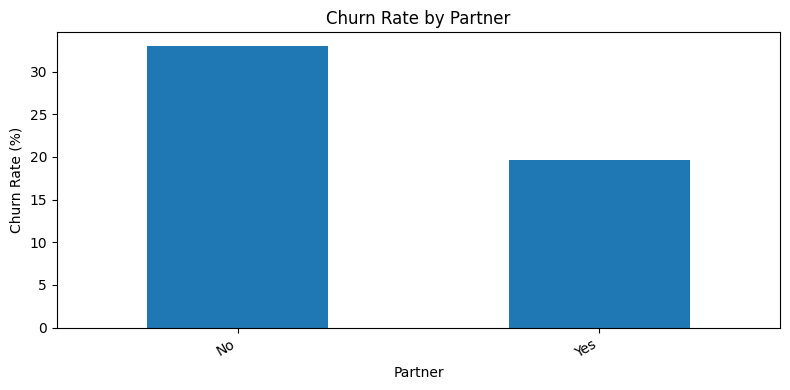

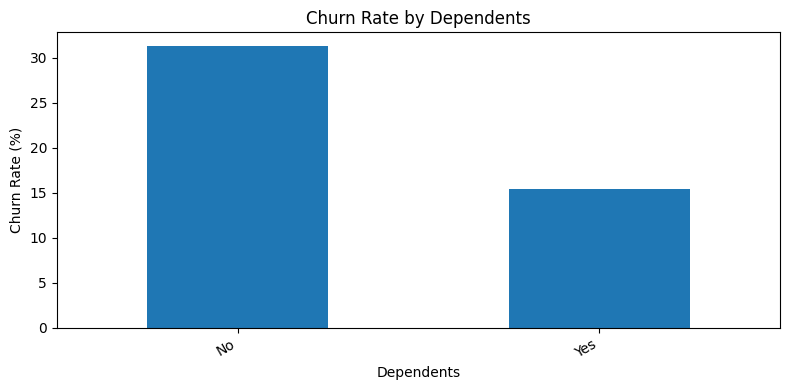

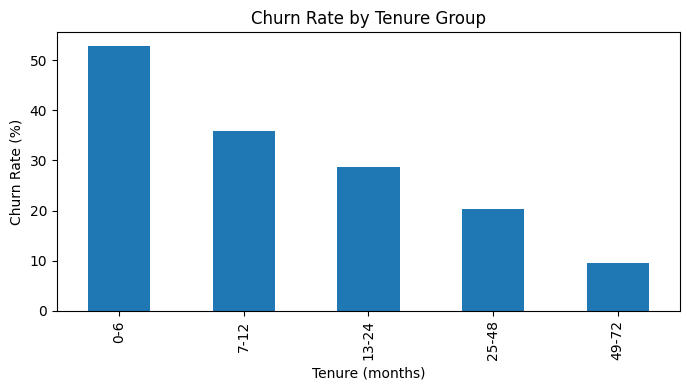

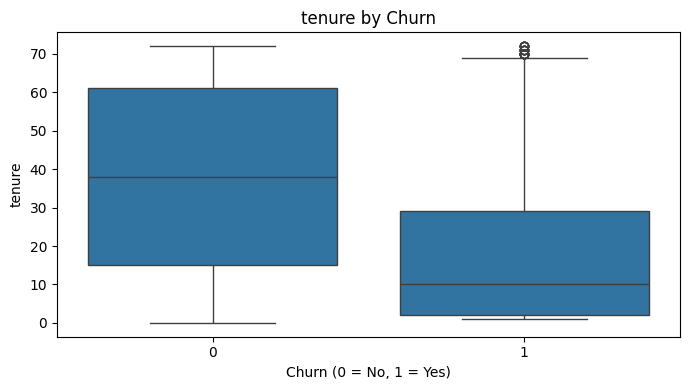

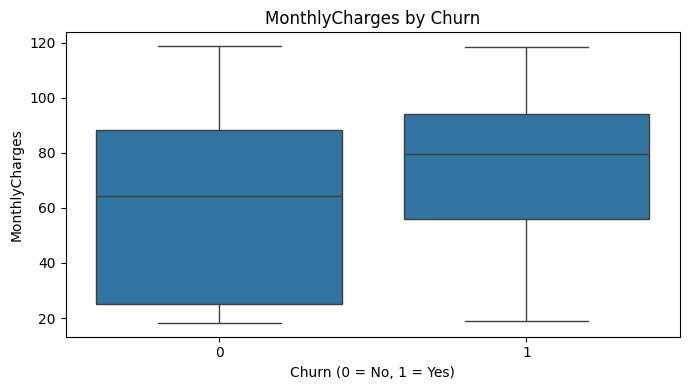

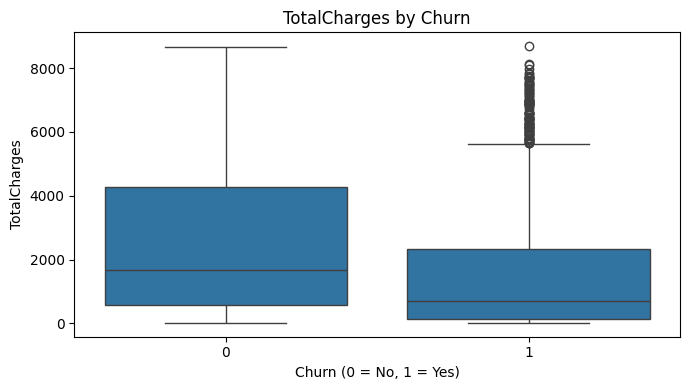

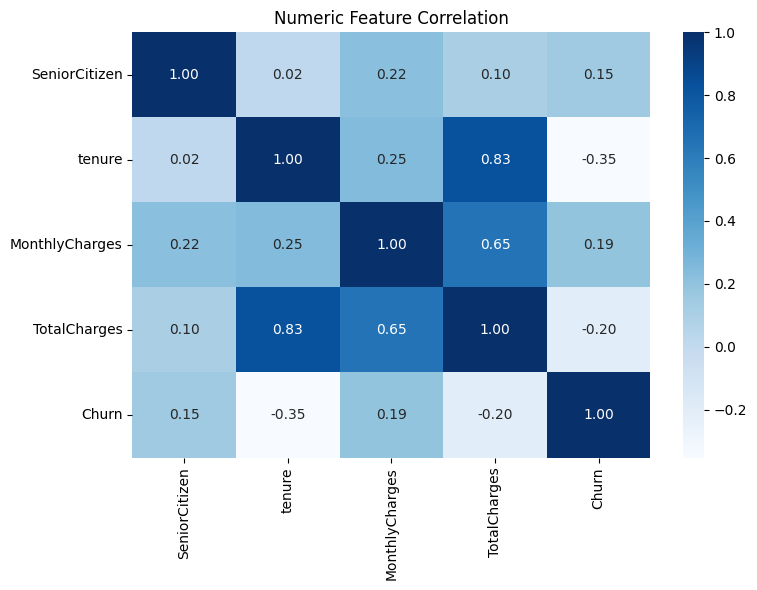

In [6]:
# Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=data["Churn"])
plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

# Churn rate by important categorical variables
eda_categoricals = [
    c for c in [
        "Contract", "InternetService", "PaymentMethod",
        "TechSupport", "OnlineSecurity", "Partner", "Dependents"
    ] if c in data.columns
]

for col in eda_categoricals:
    rates = data.groupby(col)["Churn"].mean().sort_values(ascending=False) * 100
    plt.figure(figsize=(8, 4))
    rates.plot(kind="bar")
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# Tenure groups
if "tenure" in data.columns:
    temp = data.copy()
    temp["_tenure_group"] = pd.cut(
        temp["tenure"],
        bins=[-1, 6, 12, 24, 48, 72],
        labels=["0-6", "7-12", "13-24", "25-48", "49-72"]
    )
    tenure_rates = temp.groupby("_tenure_group", observed=False)["Churn"].mean() * 100

    plt.figure(figsize=(7, 4))
    tenure_rates.plot(kind="bar")
    plt.title("Churn Rate by Tenure Group")
    plt.ylabel("Churn Rate (%)")
    plt.xlabel("Tenure (months)")
    plt.tight_layout()
    plt.show()

# Numeric distributions
numeric_for_eda = [
    c for c in ["tenure", "MonthlyCharges", "TotalCharges"]
    if c in data.columns
]

for col in numeric_for_eda:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=data["Churn"], y=data[col])
    plt.title(f"{col} by Churn")
    plt.xlabel("Churn (0 = No, 1 = Yes)")
    plt.tight_layout()
    plt.show()

# Correlation among numeric variables
numeric_corr = data.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Numeric Feature Correlation")
plt.tight_layout()
plt.show()

## 8. Business insights

In [7]:
if "Contract" in data.columns:
    contract_summary = (
        data.groupby("Contract")["Churn"]
        .agg(["count", "mean"])
        .sort_values("mean", ascending=False)
    )
    contract_summary["churn_rate_%"] = (contract_summary["mean"] * 100).round(2)
    display(contract_summary.drop(columns="mean"))

if "tenure" in data.columns:
    print("Average tenure by churn status:")
    display(
        data.groupby("Churn")["tenure"]
        .mean()
        .round(2)
        .to_frame("average_tenure_months")
    )

if "MonthlyCharges" in data.columns:
    print("Average monthly charges by churn status:")
    display(
        data.groupby("Churn")["MonthlyCharges"]
        .mean()
        .round(2)
        .to_frame("average_monthly_charges")
    )

# Highest churn-rate categories among selected categorical features
business_summary = []
for col in eda_categoricals:
    rates = data.groupby(col)["Churn"].mean()
    for category, rate in rates.items():
        business_summary.append({
            "Feature": col,
            "Category": category,
            "Churn_Rate_%": rate * 100
        })

business_summary_df = (
    pd.DataFrame(business_summary)
    .sort_values("Churn_Rate_%", ascending=False)
)

print("Highest observed churn-rate segments:")
display(business_summary_df.head(15).round(2))

,count,churn_rate_%
Contract,,
Month-to-month,3875,42.71
One year,1473,11.27
Two year,1695,2.83


Average tenure by churn status:


,average_tenure_months
Churn,
0,37.57
1,17.98


Average monthly charges by churn status:


,average_monthly_charges
Churn,
0,61.27
1,74.44


Highest observed churn-rate segments:


,Feature,Category,Churn_Rate_%
8,PaymentMethod,Electronic check,45.29
0,Contract,Month-to-month,42.71
4,InternetService,Fiber optic,41.89
13,OnlineSecurity,No,41.77
10,TechSupport,No,41.64
16,Partner,No,32.96
18,Dependents,No,31.28
17,Partner,Yes,19.66
9,PaymentMethod,Mailed check,19.11
3,InternetService,DSL,18.96


## 9. Train / validation / test split

The dataset is divided into:

- **60% training**
- **20% validation**
- **20% final test**

The validation set is used for threshold selection.

The final test set is **not used** to choose the threshold or tune hyperparameters. This gives a more credible estimate of how the finished workflow performs on unseen data.

In [8]:
X = data.drop(columns=["Churn"])
y = data["Churn"].astype(int)

# First create an untouched 20% test set.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Split the remaining 80% into 60% train and 20% validation.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_val
)

numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print(f"Train rows:      {len(X_train)} ({len(X_train)/len(X):.1%})")
print(f"Validation rows: {len(X_val)} ({len(X_val)/len(X):.1%})")
print(f"Test rows:       {len(X_test)} ({len(X_test)/len(X):.1%})")
print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)

Train rows:      4225 (60.0%)
Validation rows: 1409 (20.0%)
Test rows:       1409 (20.0%)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 10. Preprocessing pipeline

In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


## 11. Baseline and machine-learning models

In [10]:
baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

models = {
    "Baseline": baseline,
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "XGBoost": xgb
}

validation_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    prob = model.predict_proba(X_val)[:, 1]

    validation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred, zero_division=0),
        "Recall": recall_score(y_val, pred, zero_division=0),
        "F1": f1_score(y_val, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val, prob),
        "PR-AUC": average_precision_score(y_val, prob)
    })

validation_results_df = (
    pd.DataFrame(validation_results)
    .sort_values("ROC-AUC", ascending=False)
)

display(validation_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
1,Logistic Regression,0.7480,0.5166,0.7888,0.6243,0.8362,0.6424
3,XGBoost,0.7956,0.6483,0.5027,0.5663,0.8360,0.6405
2,Random Forest,0.7842,0.6306,0.4519,0.5265,0.8140,0.5975
0,Baseline,0.7346,0.0000,0.0000,0.0000,0.5000,0.2654


## 12. Detailed validation evaluation

Best initial model by validation ROC-AUC: Logistic Regression

Classification report:
              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1035
       Churn       0.52      0.79      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



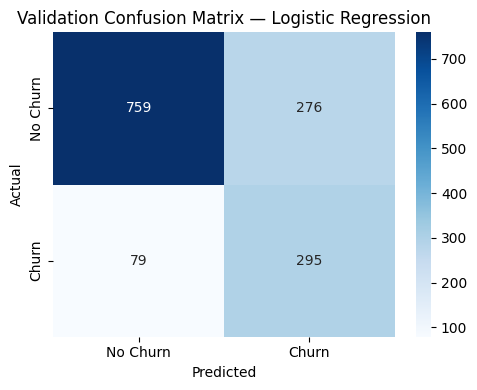

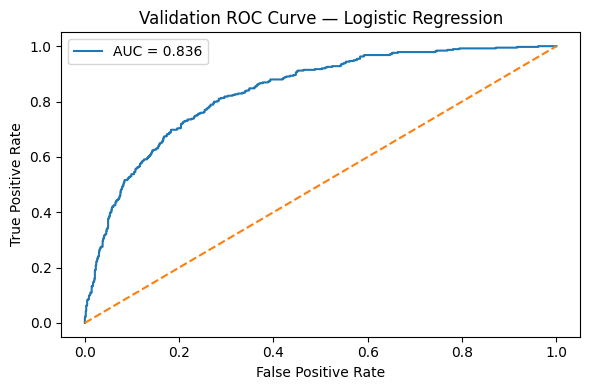

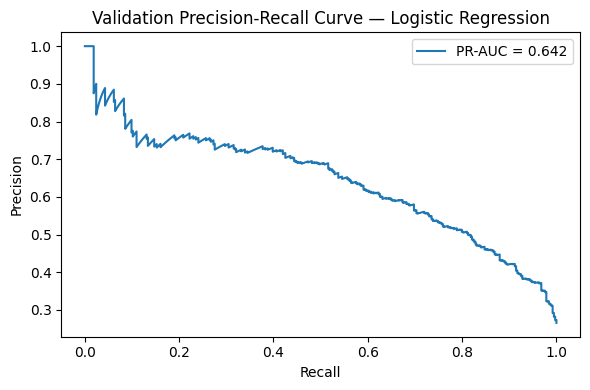

In [11]:
candidate_results = validation_results_df[
    validation_results_df["Model"] != "Baseline"
]

best_initial_name = candidate_results.iloc[0]["Model"]
best_initial_model = models[best_initial_name]

val_pred = best_initial_model.predict(X_val)
val_prob = best_initial_model.predict_proba(X_val)[:, 1]

print("Best initial model by validation ROC-AUC:", best_initial_name)
print("\nClassification report:")
print(
    classification_report(
        y_val, val_pred,
        target_names=["No Churn", "Churn"],
        zero_division=0
    )
)

cm = confusion_matrix(y_val, val_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title(f"Validation Confusion Matrix — {best_initial_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_val, val_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_val, val_prob):.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Validation ROC Curve — {best_initial_name}")
plt.legend()
plt.tight_layout()
plt.show()

precision, recall, _ = precision_recall_curve(y_val, val_prob)
plt.figure(figsize=(6, 4))
plt.plot(
    recall, precision,
    label=f"PR-AUC = {average_precision_score(y_val, val_prob):.3f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Validation Precision-Recall Curve — {best_initial_name}")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Hyperparameter tuning with cross-validation

XGBoost is tuned using **3-fold cross-validation on the training set only**.

This prevents the validation and test sets from influencing hyperparameter selection.

In [12]:
xgb_param_grid = {
    "model__n_estimators": [250, 400],
    "model__max_depth": [3, 4],
    "model__learning_rate": [0.03, 0.05],
    "model__subsample": [0.9],
    "model__colsample_bytree": [0.9]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

tuned_train_model = grid.best_estimator_

print("Best parameters:")
print(grid.best_params_)
print("\nBest 3-fold CV ROC-AUC:", round(grid.best_score_, 4))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters:
{'model__colsample_bytree': 0.9, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 250, 'model__subsample': 0.9}

Best 3-fold CV ROC-AUC: 0.8477


## 14. Validation-based threshold optimization

The model outputs a probability between 0 and 1. A threshold converts that probability into a Yes/No decision.

Here the threshold is selected on **validation data only**.

### Objective
Select the threshold that maximizes **F1-score**, with a lower threshold preferred when there is an exact F1 tie.

This is a portfolio-friendly objective because F1 balances precision and recall. In a real company, the objective should be aligned with the economics of retention campaigns.

In [13]:
# Validation probabilities from the tuned model
val_tuned_prob = tuned_train_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)
threshold_rows = []

for threshold in thresholds:
    threshold_pred = (val_tuned_prob >= threshold).astype(int)

    threshold_rows.append({
        "Threshold": round(float(threshold), 2),
        "Precision": precision_score(y_val, threshold_pred, zero_division=0),
        "Recall": recall_score(y_val, threshold_pred, zero_division=0),
        "F1": f1_score(y_val, threshold_pred, zero_division=0),
        "Accuracy": accuracy_score(y_val, threshold_pred)
    })

threshold_df = pd.DataFrame(threshold_rows)

max_f1 = threshold_df["F1"].max()
optimized_threshold = float(
    threshold_df.loc[
        threshold_df["F1"].eq(max_f1), "Threshold"
    ].min()
)

print(f"Optimized validation threshold: {optimized_threshold:.2f}")
print(f"Validation F1 at optimized threshold: {max_f1:.4f}")

display(
    threshold_df.sort_values(
        ["F1", "Recall", "Precision"],
        ascending=[False, False, False]
    ).head(10).round(4)
)

Optimized validation threshold: 0.34
Validation F1 at optimized threshold: 0.6338


,Threshold,Precision,Recall,F1,Accuracy
24,0.34,0.5649,0.7219,0.6338,0.7786
25,0.35,0.5699,0.7086,0.6317,0.7807
23,0.33,0.5547,0.7326,0.6313,0.7729
28,0.38,0.6000,0.6658,0.6312,0.7935
26,0.36,0.5765,0.6952,0.6303,0.7835
27,0.37,0.5880,0.6791,0.6303,0.7885
29,0.39,0.6090,0.6497,0.6287,0.7963
34,0.44,0.6560,0.6016,0.6276,0.8105
33,0.43,0.6415,0.6123,0.6265,0.8062
32,0.42,0.6322,0.6203,0.6262,0.8034


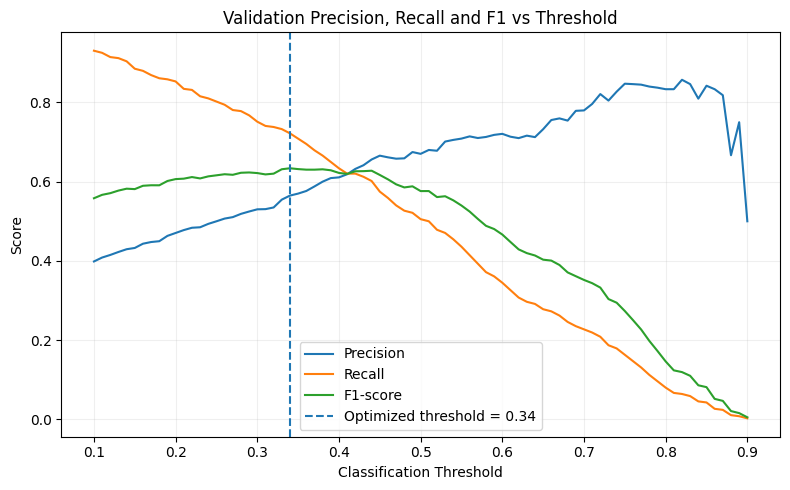

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1"], label="F1-score")
plt.axvline(
    optimized_threshold,
    linestyle="--",
    label=f"Optimized threshold = {optimized_threshold:.2f}"
)
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Validation Precision, Recall and F1 vs Threshold")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 15. Final model refit

Now that the hyperparameters and operating threshold are fixed:

1. the best tuned estimator is cloned
2. it is refit on **training + validation data**
3. the optimized validation threshold is kept unchanged
4. the final test set is evaluated exactly once

This is the cleanest separation between model development and final performance reporting.

In [15]:
# Refit the selected model on train + validation data.
final_model = clone(tuned_train_model)
final_model.fit(X_train_val, y_train_val)

# Final test probabilities and optimized-threshold predictions.
test_prob = final_model.predict_proba(X_test)[:, 1]
test_pred_optimized = (test_prob >= optimized_threshold).astype(int)

# Default 0.50 predictions for comparison.
test_pred_default = (test_prob >= 0.50).astype(int)

final_metrics = pd.DataFrame([
    {
        "Threshold": 0.50,
        "Accuracy": accuracy_score(y_test, test_pred_default),
        "Precision": precision_score(y_test, test_pred_default, zero_division=0),
        "Recall": recall_score(y_test, test_pred_default, zero_division=0),
        "F1": f1_score(y_test, test_pred_default, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, test_prob),
        "PR-AUC": average_precision_score(y_test, test_prob)
    },
    {
        "Threshold": optimized_threshold,
        "Accuracy": accuracy_score(y_test, test_pred_optimized),
        "Precision": precision_score(y_test, test_pred_optimized, zero_division=0),
        "Recall": recall_score(y_test, test_pred_optimized, zero_division=0),
        "F1": f1_score(y_test, test_pred_optimized, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, test_prob),
        "PR-AUC": average_precision_score(y_test, test_prob)
    }
])

display(final_metrics.round(4))

print(f"Optimized threshold selected on validation data: {optimized_threshold:.2f}")
print("\nFinal test classification report using optimized threshold:")
print(
    classification_report(
        y_test,
        test_pred_optimized,
        target_names=["No Churn", "Churn"],
        zero_division=0
    )
)

,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,0.50,0.8119,0.6873,0.5348,0.6015,0.8479,0.666
1,0.34,0.7757,0.5592,0.7326,0.6343,0.8479,0.666


Optimized threshold selected on validation data: 0.34

Final test classification report using optimized threshold:
              precision    recall  f1-score   support

    No Churn       0.89      0.79      0.84      1035
       Churn       0.56      0.73      0.63       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.78      1409



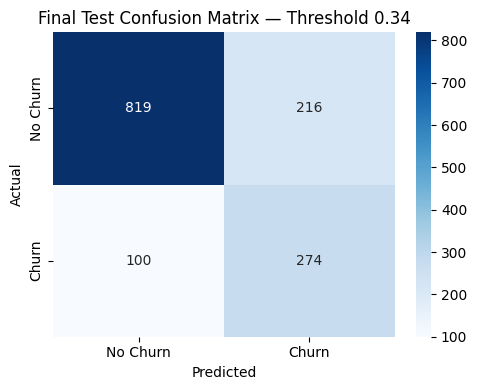

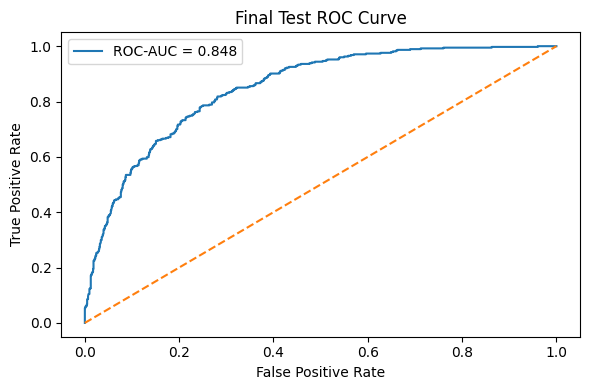

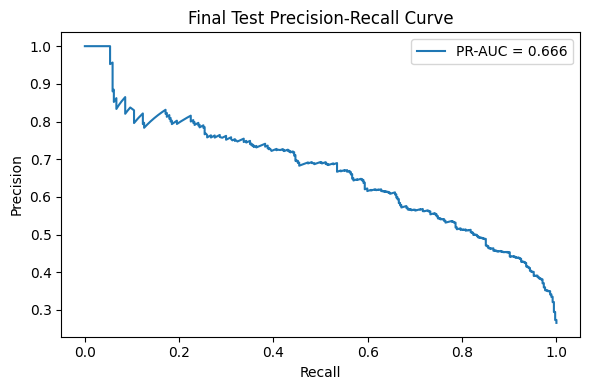

In [16]:
cm_final = confusion_matrix(y_test, test_pred_optimized)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_final, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title(f"Final Test Confusion Matrix — Threshold {optimized_threshold:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, test_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, test_prob):.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Test ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

precision, recall, _ = precision_recall_curve(y_test, test_prob)
plt.figure(figsize=(6, 4))
plt.plot(
    recall, precision,
    label=f"PR-AUC = {average_precision_score(y_test, test_prob):.3f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final Test Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

## 16. SHAP explainability

SHAP explains which transformed features push predictions toward higher or lower churn risk.

Two views are included:

- **Global importance:** which features matter most across the test sample
- **Local explanation:** why one individual customer received a particular prediction

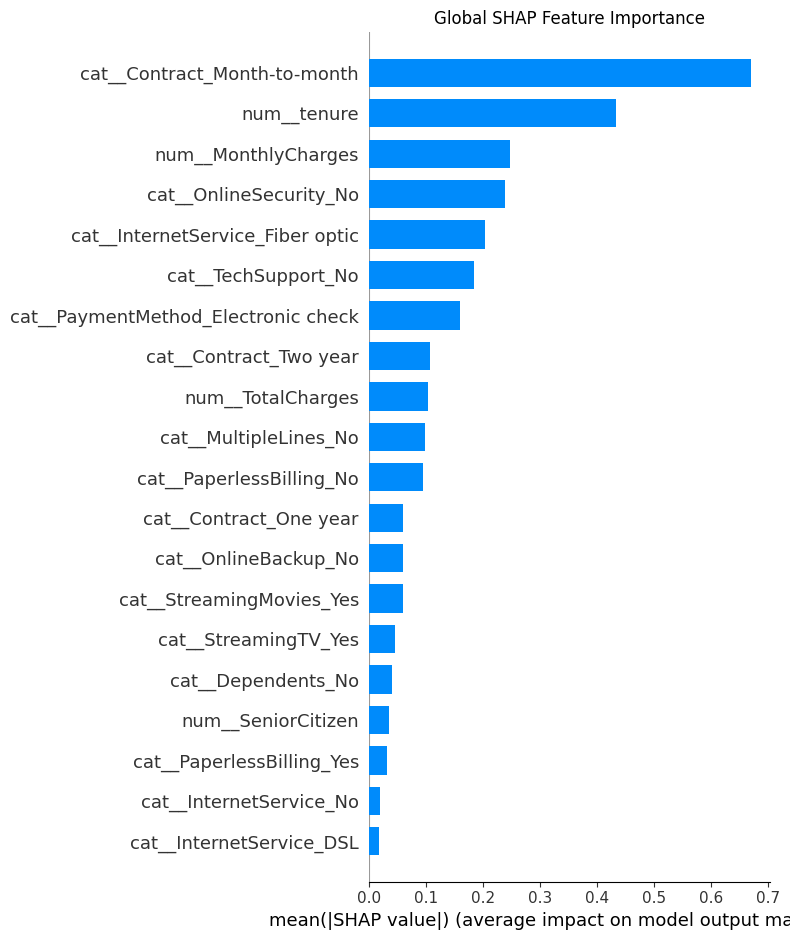

In [17]:
prep = final_model.named_steps["preprocessor"]
tree_model = final_model.named_steps["model"]

X_test_transformed = prep.transform(X_test)

try:
    feature_names = prep.get_feature_names_out()
except Exception:
    feature_names = [f"feature_{i}" for i in range(X_test_transformed.shape[1])]

shap_n = min(500, X_test_transformed.shape[0])
X_shap = X_test_transformed[:shap_n]

explainer = shap.TreeExplainer(tree_model)
shap_values_raw = explainer.shap_values(X_shap)

# Handle common SHAP output formats.
if isinstance(shap_values_raw, list):
    shap_plot_values = shap_values_raw[1]
else:
    shap_plot_values = shap_values_raw

# Some newer SHAP versions may return an extra output dimension.
if np.ndim(shap_plot_values) == 3:
    shap_plot_values = shap_plot_values[:, :, 1]

plt.figure()
shap.summary_plot(
    shap_plot_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.title("Global SHAP Feature Importance")
plt.tight_layout()
plt.show()

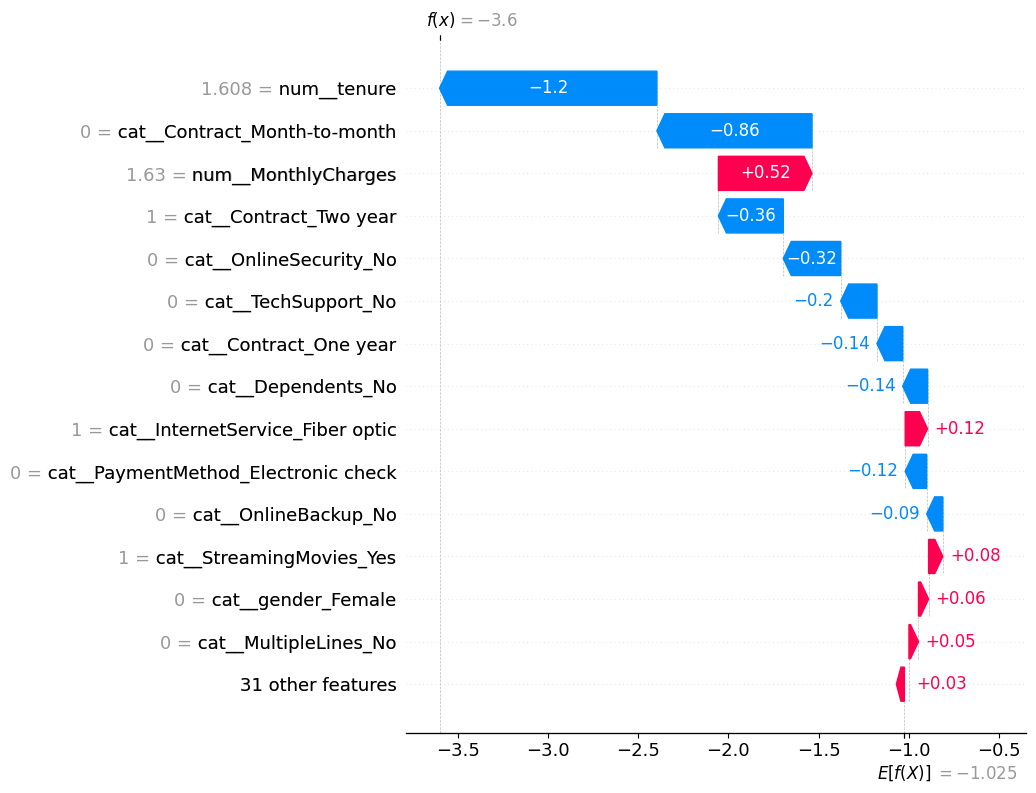

In [18]:
# Local SHAP explanation for one test customer.
customer_idx = 0
one_customer = X_test_transformed[customer_idx:customer_idx+1]
one_shap_raw = explainer.shap_values(one_customer)

try:
    if isinstance(one_shap_raw, list):
        one_shap_values = one_shap_raw[1][0]
        base_value = explainer.expected_value[1]
    else:
        one_shap_values = np.asarray(one_shap_raw)[0]
        if np.ndim(one_shap_values) == 2:
            one_shap_values = one_shap_values[:, 1]
        base_value = explainer.expected_value

    if np.ndim(base_value) > 0:
        base_value = np.asarray(base_value).reshape(-1)[0]

    explanation = shap.Explanation(
        values=one_shap_values,
        base_values=base_value,
        data=one_customer[0],
        feature_names=feature_names
    )

    shap.plots.waterfall(explanation, max_display=15)
except Exception as e:
    print("Waterfall plot could not be rendered:", e)
    print("The global SHAP importance plot is still available.")

## 17. Churn-risk segmentation

In [19]:
def risk_band(probability):
    if probability >= 0.70:
        return "High"
    elif probability >= 0.40:
        return "Medium"
    return "Low"

risk_output = X_test.copy()
risk_output["Actual_Churn"] = y_test.values
risk_output["Churn_Probability"] = test_prob
risk_output["Prediction"] = np.where(
    test_prob >= optimized_threshold, "Yes", "No"
)
risk_output["Risk_Level"] = [
    risk_band(p) for p in test_prob
]

display(
    risk_output[
        ["Actual_Churn", "Churn_Probability", "Prediction", "Risk_Level"]
    ]
    .sort_values("Churn_Probability", ascending=False)
    .head(20)
)

,Actual_Churn,Churn_Probability,Prediction,Risk_Level
3380,1,0.915518,Yes,High
6866,1,0.905657,Yes,High
4585,1,0.898911,Yes,High
6623,1,0.891837,Yes,High
2631,1,0.886460,Yes,High
2464,1,0.880132,Yes,High
2797,1,0.879240,Yes,High
6365,1,0.867094,Yes,High
383,1,0.862260,Yes,High
642,1,0.857515,Yes,High


## 18. Retention recommendations

In [20]:
monthly_charge_median = data["MonthlyCharges"].median() if "MonthlyCharges" in data.columns else 0

def retention_recommendation(row):
    actions = []

    if row.get("Contract") == "Month-to-month":
        actions.append("Offer a longer-term contract incentive")

    if row.get("MonthlyCharges", 0) >= monthly_charge_median:
        actions.append("Review pricing and offer a personalized value/discount")

    if row.get("TechSupport") == "No":
        actions.append("Offer technical support assistance")

    if row.get("OnlineSecurity") == "No":
        actions.append("Offer online security/add-on support")

    if row.get("tenure", 999) <= 12:
        actions.append("Provide an early-tenure engagement offer")

    if not actions:
        actions.append("Continue proactive engagement")

    return "; ".join(actions)

risk_output["Retention_Recommendation"] = risk_output.apply(
    retention_recommendation, axis=1
)

display(
    risk_output[
        [
            "Churn_Probability",
            "Risk_Level",
            "Contract",
            "MonthlyCharges",
            "Retention_Recommendation"
        ]
    ]
    .sort_values("Churn_Probability", ascending=False)
    .head(20)
)

,Churn_Probability,Risk_Level,Contract,MonthlyCharges,Retention_Recommendation
3380,0.915518,High,Month-to-month,95.10,Offer a longer-term contract incentive; Review...
6866,0.905657,High,Month-to-month,95.45,Offer a longer-term contract incentive; Review...
4585,0.898911,High,Month-to-month,85.05,Offer a longer-term contract incentive; Review...
6623,0.891837,High,Month-to-month,76.45,Offer a longer-term contract incentive; Review...
2631,0.886460,High,Month-to-month,99.25,Offer a longer-term contract incentive; Review...
2464,0.880132,High,Month-to-month,77.15,Offer a longer-term contract incentive; Review...
2797,0.879240,High,Month-to-month,100.95,Offer a longer-term contract incentive; Review...
6365,0.867094,High,Month-to-month,101.95,Offer a longer-term contract incentive; Review...
383,0.862260,High,Month-to-month,90.85,Offer a longer-term contract incentive; Review...
642,0.857515,High,Month-to-month,89.55,Offer a longer-term contract incentive; Review...


## 19. Business-oriented threshold interpretation

The optimized threshold is not a universal truth. It is an operating point selected for this portfolio project using validation F1.

In a real retention program:

- **Lower threshold** → contact more customers, catch more churners, but spend more on false positives.
- **Higher threshold** → contact fewer customers, reduce false positives, but risk missing churners.
- **F1 threshold** → balances precision and recall.
- **Business-cost threshold** → can directly reflect the value of saving a customer and the cost of a retention action.

This distinction is important in interviews: **the model predicts probability; the business chooses the decision policy.**

## 20. Save the complete model artifact

In [21]:
# Save everything required for consistent future predictions.
model_artifact = {
    "model": final_model,
    "threshold": optimized_threshold,
    "expected_features": X_train.columns.tolist(),
    "risk_bands": {
        "high": 0.70,
        "medium": 0.40
    },
    "target_name": "Churn",
    "random_state": RANDOM_STATE
}

joblib.dump(model_artifact, MODEL_ARTIFACT_PATH)

print(f"Saved complete model artifact to: {MODEL_ARTIFACT_PATH}")
print(f"Stored optimized threshold: {optimized_threshold:.2f}")

Saved complete model artifact to: customer_churn_model_artifact.joblib
Stored optimized threshold: 0.34


## 21. Predict completely new customers

This section simulates a simple deployment workflow.

### New customer CSV requirements
- Include the same predictor columns used during training.
- `customerID` is optional and will be preserved in the output.
- Do **not** include `Churn` for genuinely new customers.
- `TotalCharges` can be numeric or numeric text; it is converted before prediction.

In [22]:
# Upload a new-customer CSV.
try:
    from google.colab import files
    new_upload = files.upload()
    new_csvs = [name for name in new_upload.keys() if name.lower().endswith(".csv")]
    if not new_csvs:
        raise FileNotFoundError("Please upload a CSV containing new customers.")
    NEW_DATA_PATH = new_csvs[0]
except ImportError:
    NEW_DATA_PATH = "new_customers.csv"
    if not os.path.exists(NEW_DATA_PATH):
        raise FileNotFoundError(
            "For local use, place your new customer file at 'new_customers.csv'."
        )

new_customers = pd.read_csv(NEW_DATA_PATH)

print("New customer data shape:", new_customers.shape)
display(new_customers.head())

Saving new_customers.csv to new_customers (1).csv
New customer data shape: (10, 20)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,NEWCUST001,Female,0,Yes,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.80
1,NEWCUST002,Male,0,No,No,41,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45
2,NEWCUST003,Female,0,Yes,Yes,52,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.70
3,NEWCUST004,Female,0,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35
4,NEWCUST005,Male,0,No,No,67,Yes,No,DSL,No,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.10


In [23]:
# Load the saved artifact exactly as a deployment process would.
artifact = joblib.load(MODEL_ARTIFACT_PATH)

model_for_prediction = artifact["model"]
prediction_threshold = float(artifact["threshold"])
expected_features = artifact["expected_features"]
risk_cutoffs = artifact["risk_bands"]

prediction_input = new_customers.copy()

# Preserve customer IDs for output.
if "customerID" in prediction_input.columns:
    customer_ids = prediction_input["customerID"].copy()
    model_input = prediction_input.drop(columns=["customerID"])
else:
    customer_ids = pd.Series(
        [f"NEW_{i+1:04d}" for i in range(len(prediction_input))],
        index=prediction_input.index,
        name="customerID"
    )
    model_input = prediction_input.copy()

# Never use a target column as an input feature.
if "Churn" in model_input.columns:
    model_input = model_input.drop(columns=["Churn"])

# Match training data types expected by the pipeline.
if "TotalCharges" in model_input.columns:
    model_input["TotalCharges"] = pd.to_numeric(
        model_input["TotalCharges"], errors="coerce"
    )

# Validate required columns.
missing_features = [
    c for c in expected_features if c not in model_input.columns
]

if missing_features:
    raise ValueError(
        "The new data is missing required columns:\n"
        + "\n".join(missing_features)
    )

# Ignore extra columns and preserve the exact training feature order.
model_input = model_input[expected_features]

new_prob = model_for_prediction.predict_proba(model_input)[:, 1]
new_pred = (new_prob >= prediction_threshold).astype(int)

new_results = pd.DataFrame({
    "customerID": customer_ids.values,
    "Churn_Probability": new_prob,
    "Prediction": np.where(new_pred == 1, "Yes", "No"),
    "Risk_Level": [risk_band(p) for p in new_prob]
})

# Add useful customer fields when available.
for col in ["Contract", "InternetService", "tenure", "MonthlyCharges"]:
    if col in prediction_input.columns:
        new_results[col] = prediction_input[col].values

new_results["Retention_Recommendation"] = prediction_input.apply(
    retention_recommendation, axis=1
)

print(f"Predictions generated using optimized threshold = {prediction_threshold:.2f}")
display(
    new_results.sort_values(
        "Churn_Probability", ascending=False
    ).reset_index(drop=True)
)

Predictions generated using optimized threshold = 0.34


,customerID,Churn_Probability,Prediction,Risk_Level,Contract,InternetService,tenure,MonthlyCharges,Retention_Recommendation
0,NEWCUST004,0.780381,Yes,High,Month-to-month,Fiber optic,1,76.35,Offer a longer-term contract incentive; Review...
1,NEWCUST001,0.728965,Yes,High,Month-to-month,DSL,1,24.80,Offer a longer-term contract incentive; Offer ...
2,NEWCUST010,0.296875,No,Low,Month-to-month,No,1,19.40,Offer a longer-term contract incentive; Provid...
3,NEWCUST006,0.291336,No,Low,Month-to-month,Fiber optic,68,89.60,Offer a longer-term contract incentive; Review...
4,NEWCUST009,0.133199,No,Low,Two year,Fiber optic,70,104.00,Review pricing and offer a personalized value/...
5,NEWCUST002,0.099741,No,Low,Month-to-month,No,41,25.25,Offer a longer-term contract incentive
6,NEWCUST007,0.024303,No,Low,Two year,DSL,23,77.15,Review pricing and offer a personalized value/...
7,NEWCUST005,0.023013,No,Low,Two year,DSL,67,50.55,Offer online security/add-on support
8,NEWCUST003,0.013363,No,Low,Two year,No,52,19.35,Continue proactive engagement
9,NEWCUST008,0.007215,No,Low,Two year,DSL,72,72.10,Review pricing and offer a personalized value/...


## 22. Export predictions as CSV

In [24]:
new_results.to_csv(PREDICTIONS_PATH, index=False)

print(f"Prediction file saved as: {PREDICTIONS_PATH}")

try:
    from google.colab import files
    files.download(PREDICTIONS_PATH)
except ImportError:
    print("Local environment detected. The CSV is available in the current working directory.")

Prediction file saved as: customer_churn_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 23. Portfolio conclusion

### What this project demonstrates

**Data skills**
- Data cleaning
- Missing-value handling
- Feature-type handling
- Exploratory data analysis
- Business-oriented segmentation

**Machine learning**
- Stratified train/validation/test splitting
- Preprocessing pipelines
- Baseline modeling
- Logistic Regression
- Random Forest
- XGBoost
- Cross-validated hyperparameter tuning
- Class-imbalance handling
- Threshold optimization

**Model evaluation**
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Confusion matrix
- ROC and Precision-Recall curves

**Explainable AI**
- Global SHAP feature importance
- Local SHAP explanation

**Deployment mindset**
- Saved model + threshold artifact
- Input validation
- New-customer prediction
- Risk levels
- Retention recommendations
- CSV export

